# Notebook 5: LightGBM Hybrid Model

Tsay's test showed CPU is nonlinear — this motivates a ML approach.

This notebook:
- Engineers lag features and rolling statistics
- Trains LightGBM for EPU, CPU, GPR
- Explains predictions using SHAP values
- Final comparison: ARIMAX vs SARIMA vs LightGBM

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'EPU': '#2563EB', 'CPU': '#16A34A', 'GPR': '#DC2626'}

def mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))

print('Ready.')

Ready.


In [33]:
# Load data
df_proc = pd.read_csv('../data/processed/df_transformed.csv', parse_dates=['Date'], index_col='Date')
df_feat = pd.read_excel('../data/processed/filtered_data.xlsx')
granger = pd.read_excel('../data/processed/granger_causality_results.xlsx')
df_feat = df_feat.iloc[-len(df_proc):]
df_feat.index = df_proc.index
HORIZON = 12
print(f'Data loaded. Features: {df_feat.shape}')

Data loaded. Features: (434, 62)


## 1. Feature Engineering

In [34]:
def engineer_features(df, target, granger_df, exog_df, n_exog=15):
    series = df[target].dropna()
    feat   = pd.DataFrame(index=series.index)
    feat['target'] = series.values

    # Lag features
    for lag in [1, 2, 3, 6, 12]:
        feat[f'lag_{lag}'] = series.shift(lag)

    # Rolling stats
    for window in [3, 6]:
        feat[f'roll_mean_{window}'] = series.shift(1).rolling(window).mean()
        feat[f'roll_std_{window}']  = series.shift(1).rolling(window).std()

    # Cyclic month encoding
    feat['month_sin'] = np.sin(2 * np.pi * feat.index.month / 12)
    feat['month_cos'] = np.cos(2 * np.pi * feat.index.month / 12)

    # Granger-selected exogenous features
    sig = granger_df[
        (granger_df['Target Variable'] == target) &
        (granger_df['Result'] == 'Significant')
    ].nsmallest(n_exog, 'Min P-Value')['Feature'].tolist()
    sig = [f for f in sig if f in exog_df.columns]
    for f in sig:
        feat[f'exog_{f}'] = exog_df[f].reindex(feat.index).shift(1)

    return feat.dropna()

feature_sets = {}
for target in ['EPU', 'CPU', 'GPR']:
    features = engineer_features(df_proc, target, granger, df_feat)
    feature_sets[target] = features
    print(f'{target}: {features.shape[0]} samples, {features.shape[1]-1} features')

EPU: 422 samples, 16 features
CPU: 422 samples, 26 features
GPR: 422 samples, 13 features


## 2. Train LightGBM

In [35]:
lgbm_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 10,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

lgbm_results = {}
lgbm_models  = {}

for target in ['EPU', 'CPU', 'GPR']:
    feat = feature_sets[target]
    X = feat.drop(columns='target')
    y = feat['target']

    X_train, X_test = X.iloc[:-HORIZON], X.iloc[-HORIZON:]
    y_train, y_test = y.iloc[:-HORIZON], y.iloc[-HORIZON:]

    val_size = min(24, len(X_train)//5)
    X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
    y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

    model = lgb.LGBMRegressor(**lgbm_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)])

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mape_val = mape(y_test.values, y_pred)
    r2   = r2_score(y_test, y_pred)

    lgbm_results[target] = {
        'y_train': y_train, 'y_test': y_test, 'y_pred': y_pred,
        'RMSE': rmse, 'MAE': mae, 'MAPE': mape_val, 'R2': r2
    }
    lgbm_models[target] = (model, X_train, X_test)
    print(f'{target}: RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape_val:.2f}%  R2={r2:.2f}')

EPU: RMSE=35.92  MAE=30.26  MAPE=16.33%  R2=-1.32
CPU: RMSE=52.37  MAE=40.91  MAPE=197.74%  R2=0.23
GPR: RMSE=10.67  MAE=9.46  MAPE=7.89%  R2=0.21


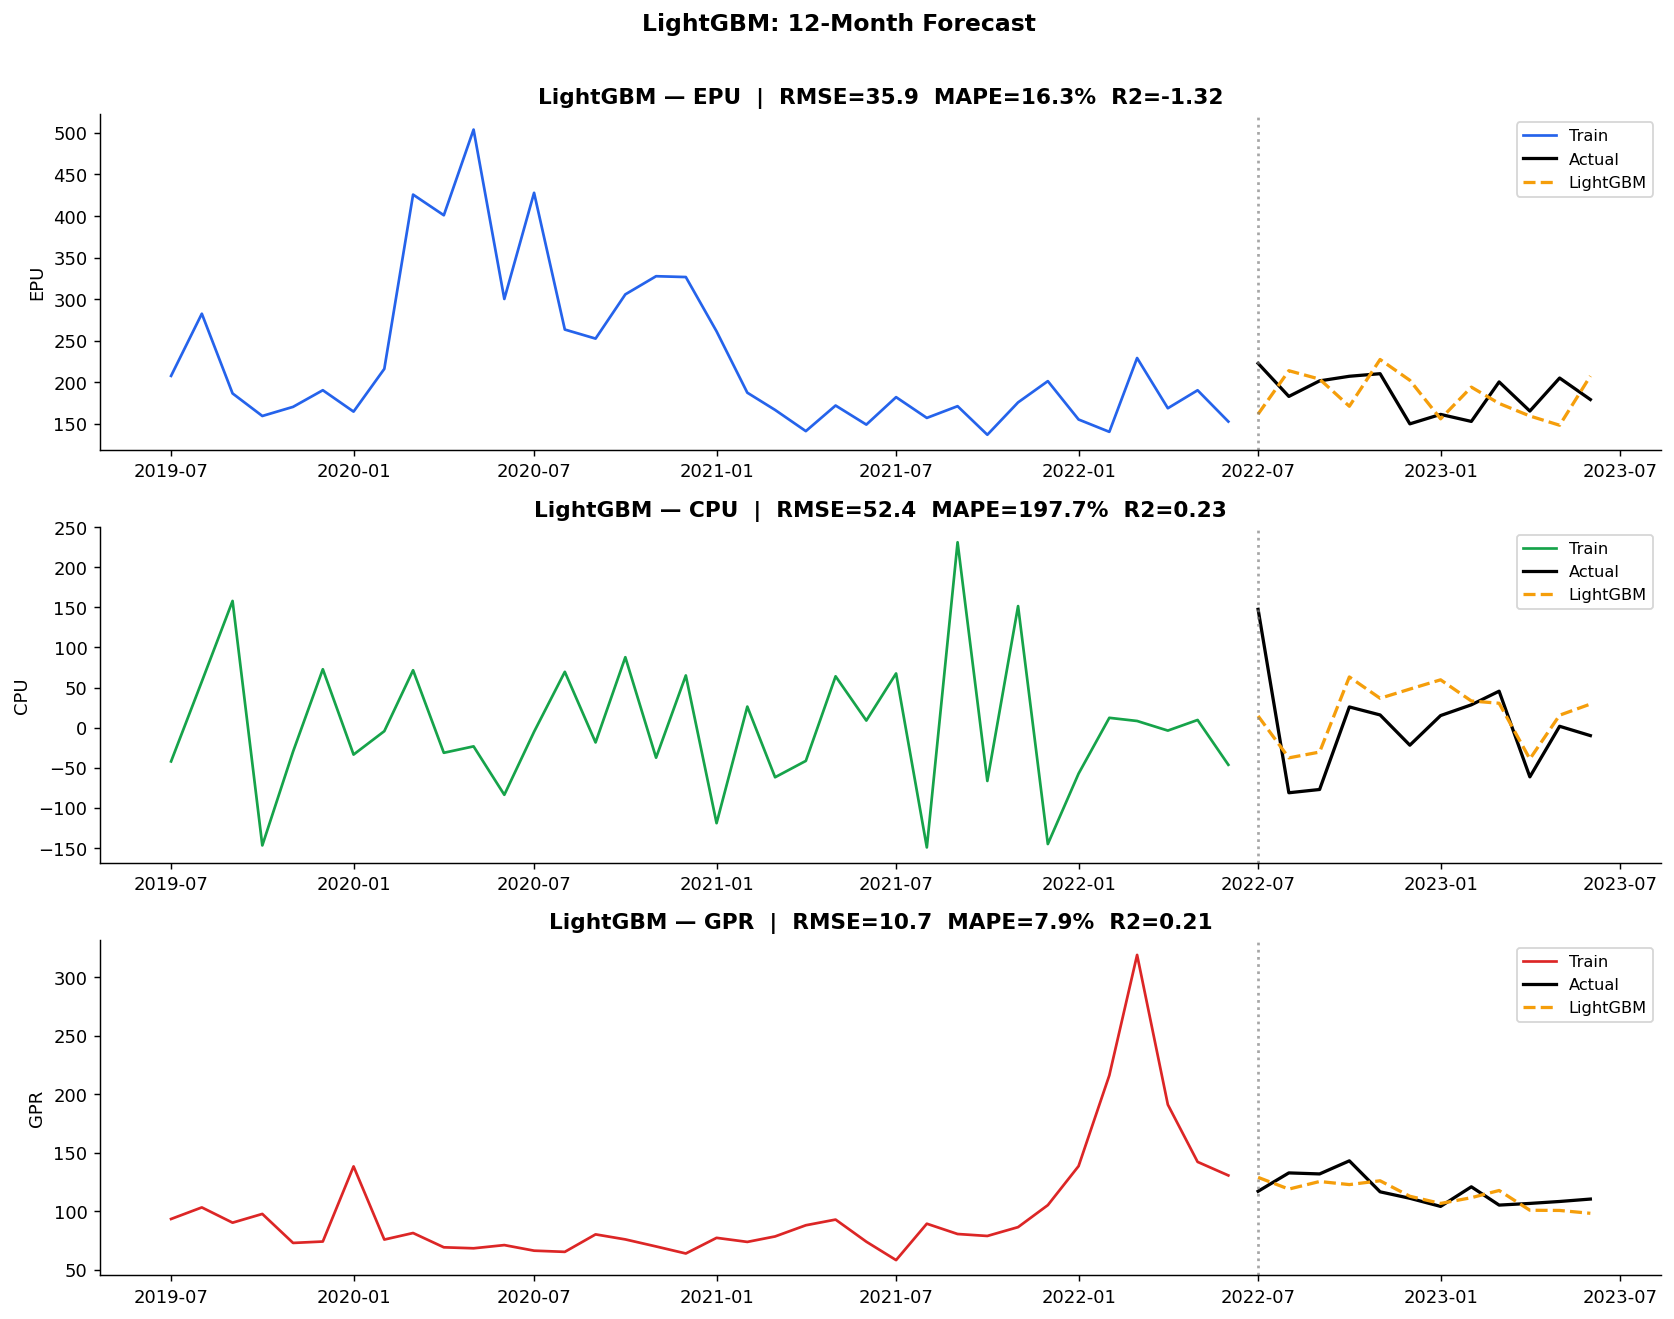

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, target in zip(axes, ['EPU', 'CPU', 'GPR']):
    res = lgbm_results[target]
    y_train, y_test = res['y_train'], res['y_test']
    y_pred = pd.Series(res['y_pred'], index=y_test.index)
    ax.plot(y_train.index[-36:], y_train.values[-36:], color=COLORS[target], linewidth=1.5, label='Train')
    ax.plot(y_test.index, y_test.values, color='black', linewidth=1.8, label='Actual')
    ax.plot(y_pred.index, y_pred.values, color='#F59E0B', linewidth=1.8, linestyle='--', label='LightGBM')
    ax.axvline(y_test.index[0], color='gray', linestyle=':', alpha=0.7)
    metrics = f"RMSE={res['RMSE']:.1f}  MAPE={res['MAPE']:.1f}%  R2={res['R2']:.2f}"
    ax.set_title(f'LightGBM — {target}  |  {metrics}', fontweight='bold')
    ax.set_ylabel(target)
    ax.legend(fontsize=9)
plt.suptitle('LightGBM: 12-Month Forecast', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/14_lgbm_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SHAP Feature Importance

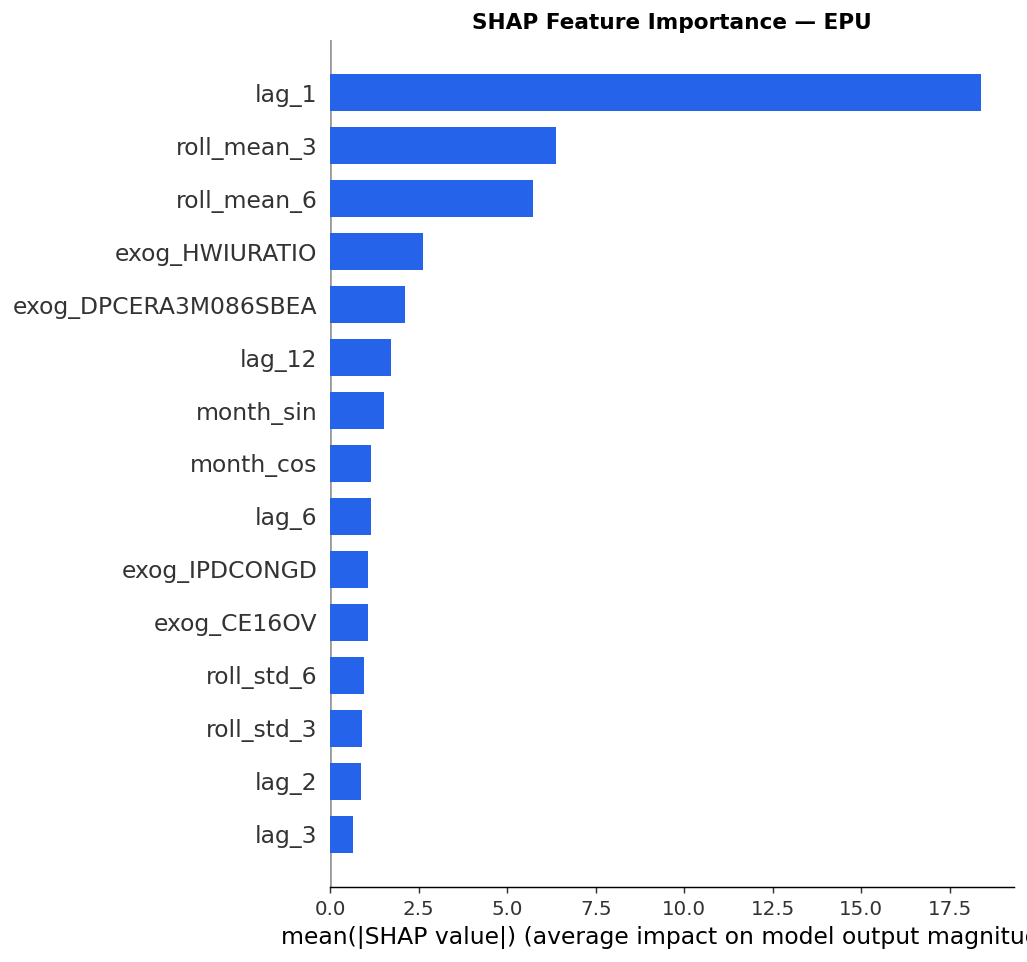

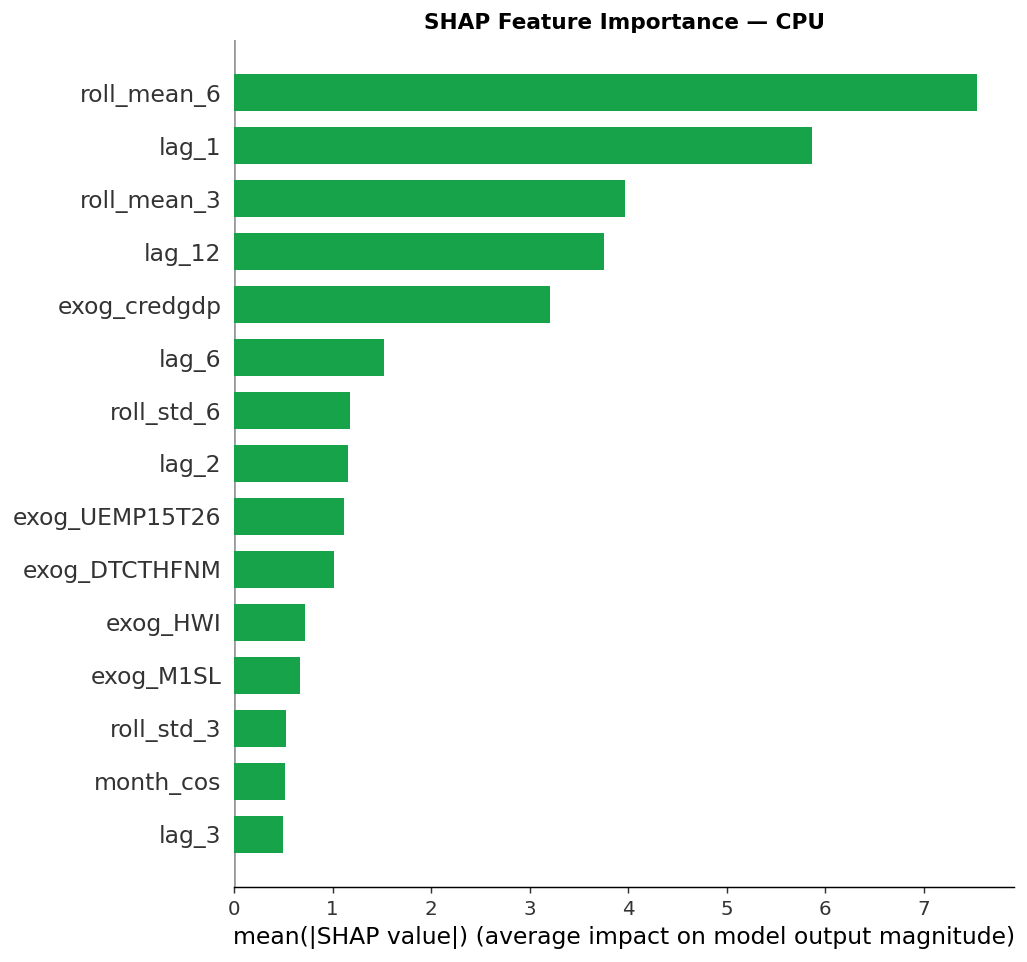

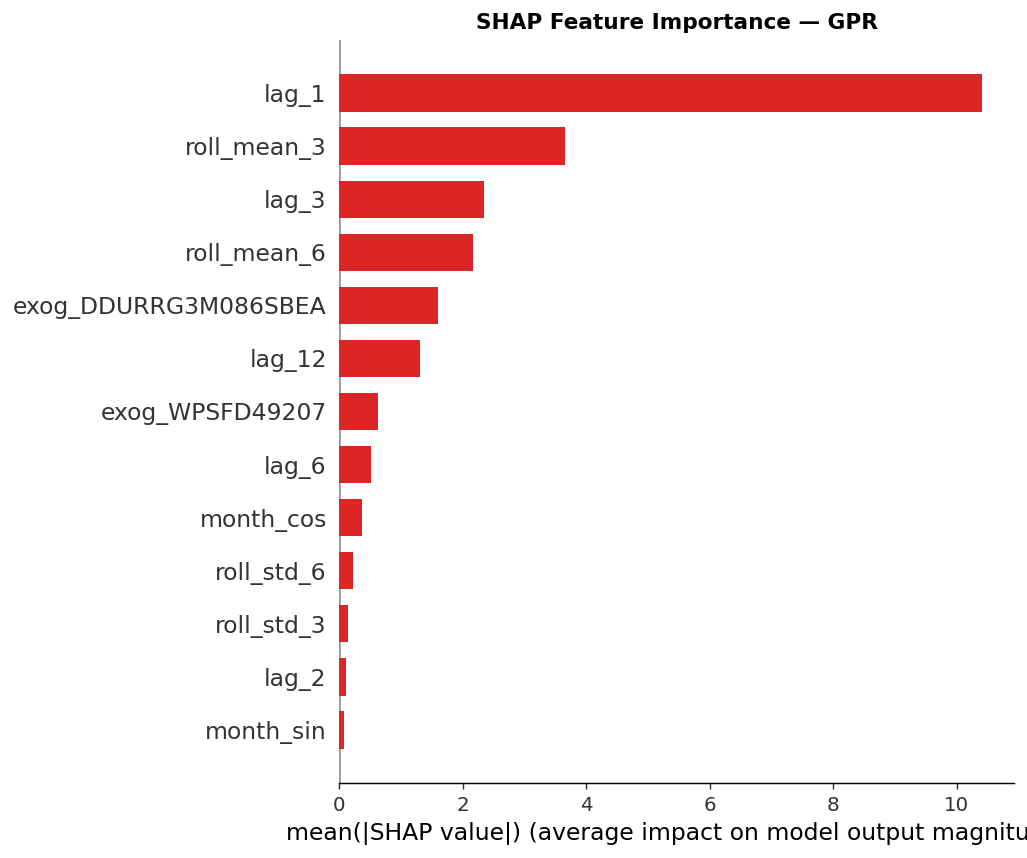

In [37]:
for target in ['EPU', 'CPU', 'GPR']:
    model, X_train, X_test = lgbm_models[target]
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    fig, ax = plt.subplots(figsize=(9, 5))
    shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=15, show=False, color=COLORS[target])
    plt.title(f'SHAP Feature Importance — {target}', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../outputs/15_shap_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Final Comparison — All Models

In [38]:
try:
    ts_comparison = pd.read_csv('../outputs/model_comparison.csv')
except FileNotFoundError:
    print('Run Notebook 4 first to generate model_comparison.csv')
    ts_comparison = pd.DataFrame()

lgbm_rows = []
for target in ['EPU', 'CPU', 'GPR']:
    r = lgbm_results[target]
    lgbm_rows.append({'Model': 'LightGBM', 'Target': target,
                      'RMSE': round(r['RMSE'],2), 'MAE': round(r['MAE'],2),
                      'MAPE': round(r['MAPE'],2), 'R2': round(r['R2'],3)})

all_results = pd.concat([ts_comparison, pd.DataFrame(lgbm_rows)], ignore_index=True)
all_results.to_csv('../outputs/all_models_comparison.csv', index=False)
print(all_results.sort_values(['Target','RMSE']).to_string(index=False))

   Model Target  RMSE   MAE   MAPE     R2
LightGBM    CPU 52.37 40.91 197.74  0.227
  SARIMA    CPU 52.75 41.23  95.98  0.215
  ARIMAX    CPU 58.71 45.14 135.60  0.028
  SARIMA    EPU 23.18 17.64  10.11  0.036
  ARIMAX    EPU 24.16 21.67  11.68 -0.047
LightGBM    EPU 35.92 30.26  16.33 -1.316
  SARIMA    GPR  9.81  7.54   6.56  0.330
LightGBM    GPR 10.67  9.46   7.89  0.208
  ARIMAX    GPR 11.37  8.46   6.74  0.100


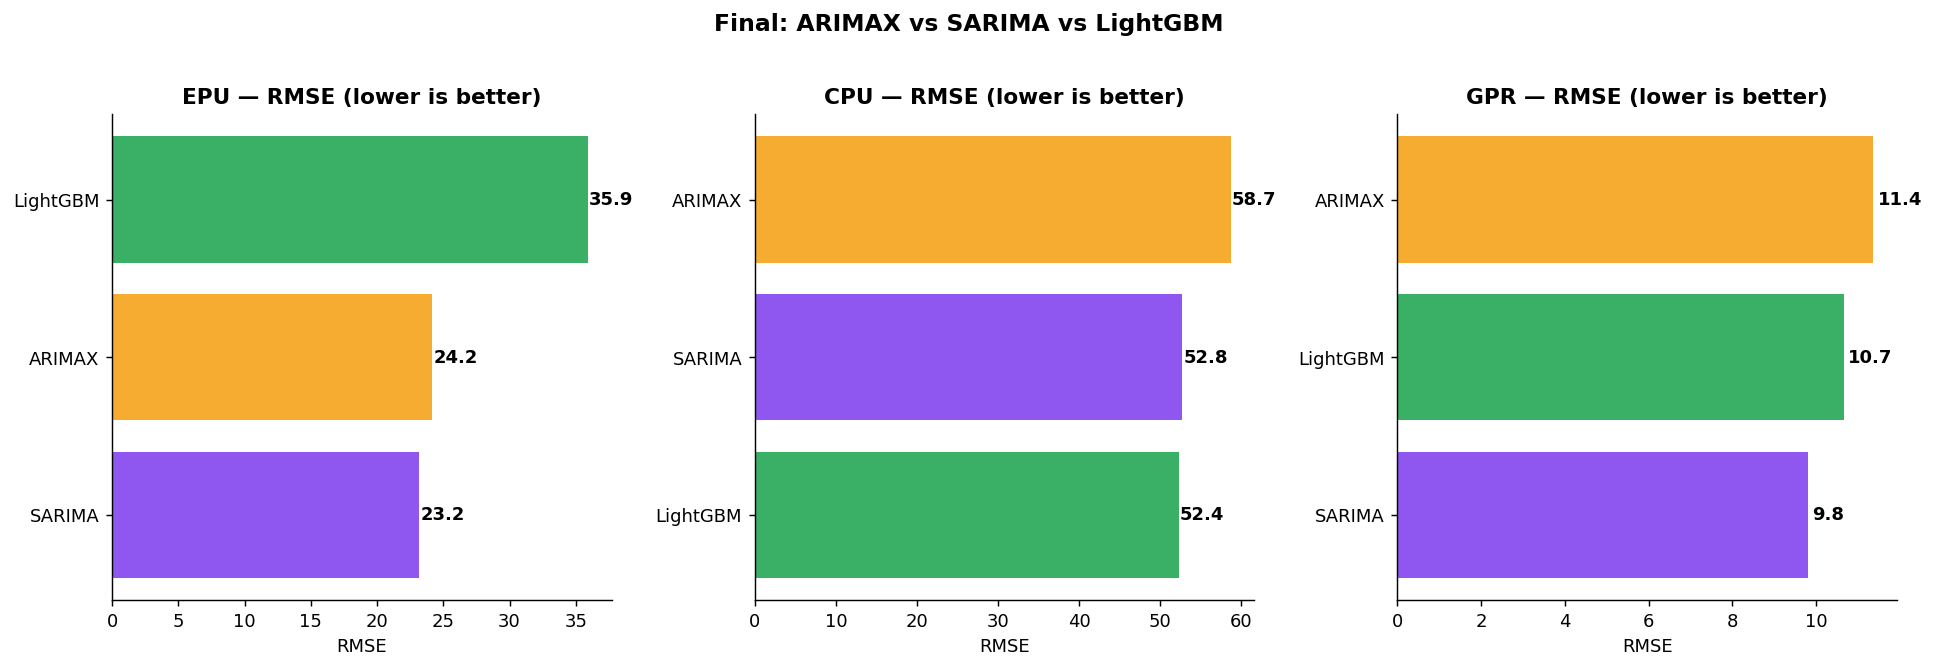

All done. Notebooks complete.


In [39]:
model_colors = {'ARIMAX': '#F59E0B', 'SARIMA': '#7C3AED', 'LightGBM': '#16A34A'}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, ['EPU', 'CPU', 'GPR']):
    sub = all_results[all_results['Target'] == target].sort_values('RMSE')
    bars = ax.barh(sub['Model'], sub['RMSE'],
                   color=[model_colors.get(m,'gray') for m in sub['Model']], alpha=0.85)
    for bar, val in zip(bars, sub['RMSE']):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}', va='center', fontweight='bold')
    ax.set_title(f'{target} — RMSE (lower is better)', fontweight='bold')
    ax.set_xlabel('RMSE')
plt.suptitle('Final: ARIMAX vs SARIMA vs LightGBM', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/16_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('All done. Notebooks complete.')